# Harmenberg's Neutral Measure: 1D Grid with Varying PermGroFac

**MC vs TM comparison for a 5-state Markov model — same as `serial-growth-tm-2d.ipynb`,
but using Harmenberg (2021)'s permanent-income-neutral measure to collapse the 2D
$(m, p)$ grid back to a 1D grid over $m$ alone.**

## Why the neutral measure?

In `serial-growth-tm-2d.ipynb` we saw that when PermGroFac $\neq$ 1.0:

- The 2D grid $(m \times p)$ is expensive: $M \times P \times J$ states
- The $p$-grid must be wide enough to capture the ergodic distribution of $p$
- Level aggregates suffered ~30% error from $p$-grid truncation

**Harmenberg's insight:** reweight the permanent shock probabilities by $\psi$:

$$P^*(\psi_k) = \psi_k \cdot P(\psi_k)$$

Under this "neutral measure":
- $E^*[1/\psi] = E[\psi \cdot (1/\psi)] = 1$, so the $m$-transition
  doesn't depend on $p$
- The distribution collapses to $m \times J$ states (1D grid!)
- Level aggregates recover as $C_{\text{level}} = E^*[c(m)] \times \bar{p}$,
  where $\bar{p}$ is the mean permanent income

| Approach | Grid states | Memory (80 m-pts, 25 p-pts, 5 Markov) |
|----------|------------|----------------------------------------|
| 2D grid  | $M \times P \times J = 10{,}000$ | ~800 MB |
| Neutral measure | $M \times J = 400$ | ~1.3 MB |

---

In [1]:
import time
from copy import copy

import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse.linalg as sp_linalg

from HARK.ConsumptionSaving.ConsMarkovModel import (
    MarkovConsumerType,
    init_indshk_markov,
)
from HARK.ConsumptionSaving.ConsMarkovModel import make_markov_solution_terminal
from HARK.Calibration.Income.IncomeProcesses import (
    construct_lognormal_income_process_unemployment,
)
from HARK.utilities import make_grid_exp_mult, jump_to_grid_1D

COLOR_MC = "tab:blue"
COLOR_TM = "tab:orange"
BURNIN = 400
N_MC_BINS = 200

## 1. Model Setup

Identical to the 2D notebook: 5 Markov states with persistence 0.5,
same Rfree, LivPrb, income process — only PermGroFac varies.

In [2]:
J = 5
Persistence = 0.5
PermGroFac_vals = np.array([0.97, 0.99, 1.01, 1.03, 1.05])
state_names = [f"PermGroFac={g:.2f}" for g in PermGroFac_vals]

MrkvArray = np.zeros((J, J))
for j_from in range(J):
    for j_to in range(J):
        if j_from == j_to:
            MrkvArray[j_from, j_to] = Persistence
        else:
            MrkvArray[j_from, j_to] = (1.0 - Persistence) / (J - 1)

print("Markov transition matrix (row-stochastic):")
print(np.array2string(MrkvArray, precision=3))
print(f"Row sums: {MrkvArray.sum(axis=1)}")

eigvals, eigvecs = np.linalg.eig(MrkvArray.T)
idx = np.argmin(np.abs(eigvals - 1.0))
markov_stationary = eigvecs[:, idx].real
markov_stationary = markov_stationary / markov_stationary.sum()
print(f"Stationary distribution: {markov_stationary}")

Markov transition matrix (row-stochastic):
[[0.5   0.125 0.125 0.125 0.125]
 [0.125 0.5   0.125 0.125 0.125]
 [0.125 0.125 0.5   0.125 0.125]
 [0.125 0.125 0.125 0.5   0.125]
 [0.125 0.125 0.125 0.125 0.5  ]]
Row sums: [1. 1. 1. 1. 1.]
Stationary distribution: [0.2 0.2 0.2 0.2 0.2]


## 2. Solve the Model

The solution is computed once; it does not depend on which measure we use
for the transition matrix.

In [3]:
# STANDARD income distribution (for solving the model and MC simulation)
std_dstn_list = construct_lognormal_income_process_unemployment(
    T_cycle=1,
    PermShkStd=[0.1],
    PermShkCount=5,
    TranShkStd=[0.1],
    TranShkCount=5,
    T_retire=0,
    UnempPrb=0.05,
    IncUnemp=0.3,
    UnempPrbRet=None,
    IncUnempRet=None,
    RNG=np.random.default_rng(0),
    neutral_measure=False,
)
std_dstn = std_dstn_list[0]

IncShkDstn_J = [std_dstn] * J

print(f"Standard income shocks: {len(std_dstn.atoms[0])} shock points")
print(
    f"Perm shock range: [{std_dstn.atoms[0].min():.4f}, {std_dstn.atoms[0].max():.4f}]"
)
print(f"Sum of pmv: {std_dstn.pmv.sum():.6f}")

Standard income shocks: 30 shock points
Perm shock range: [0.8660, 1.1458]
Sum of pmv: 1.000000


In [4]:
params = copy(init_indshk_markov)
params["cycles"] = 0
params["AgentCount"] = 50000
params["T_sim"] = 1200
params["Rfree"] = [np.array(J * [1.03])]
params["LivPrb"] = [np.array(J * [0.98])]
params["PermGroFac"] = [PermGroFac_vals]
params["MrkvPrbsInit"] = markov_stationary
params["Mrkv_p11"] = [0.5]
params["Mrkv_p22"] = [0.5]
params["global_markov"] = False

agent = MarkovConsumerType(**params)
agent.assign_parameters(MrkvArray=[MrkvArray])
agent.IncShkDstn = [IncShkDstn_J]
agent.solution_terminal = make_markov_solution_terminal(agent.CRRA, agent.MrkvArray)

agent.solve()
print(f"Solved: {len(agent.solution[0].cFunc)} consumption functions")
print(f"PermGroFac used: {agent.PermGroFac[0]}")

Solved: 5 consumption functions
PermGroFac used: [0.97 0.99 1.01 1.03 1.05]


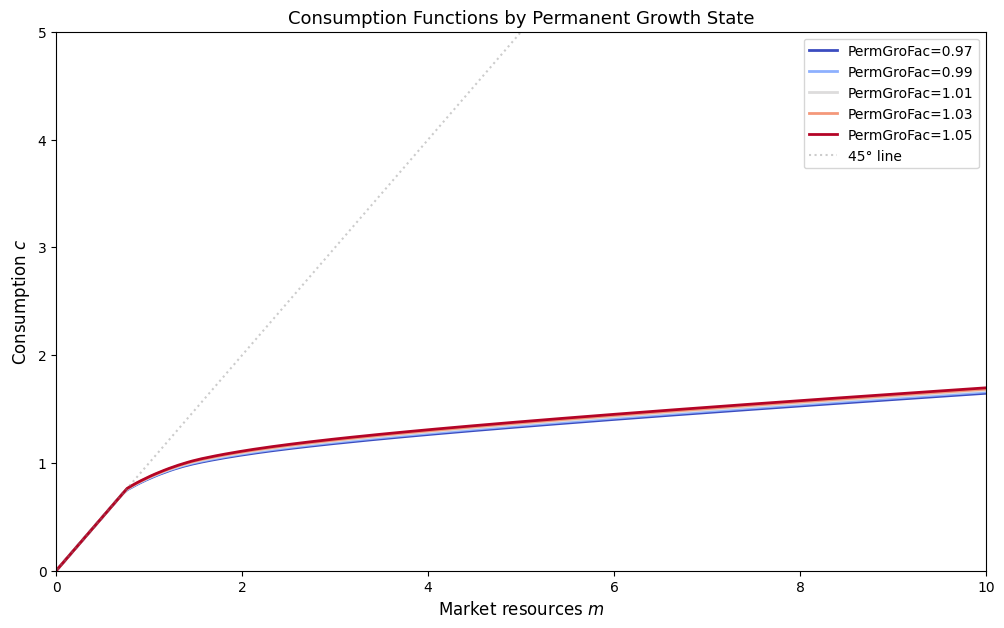

In [5]:
# [consumption_functions_by_state]
m_plot = np.linspace(0.01, 10, 200)

plt.figure(figsize=(12, 7))
cmap = plt.cm.coolwarm
for j in range(J):
    c_vals = agent.solution[0].cFunc[j](m_plot)
    color = cmap(j / (J - 1))
    plt.plot(m_plot, c_vals, label=state_names[j], linewidth=2, color=color)
plt.plot(m_plot, m_plot, ":", color="gray", alpha=0.4, label="45° line")
plt.xlabel("Market resources $m$", fontsize=12)
plt.ylabel("Consumption $c$", fontsize=12)
plt.title("Consumption Functions by Permanent Growth State", fontsize=13)
plt.legend(fontsize=10)
plt.xlim([0, 10])
plt.ylim([0, 5])
plt.tight_layout()
plt.show()

## 3. Monte Carlo Simulation

Same as the 2D notebook.  We'll use the MC results as the ground truth
for both normalized and level aggregates.

In [6]:
agent.track_vars = ["aNrm", "mNrm", "pLvl", "Mrkv"]
agent.initialize_sim()
agent.t_age = np.ones(agent.AgentCount, dtype=int)  # avoid newborn TranShk=1 bias

t0_mc = time.time()
agent.simulate()
mc_sim_time = time.time() - t0_mc
n_agents = agent.AgentCount
print(f"MC simulation: {mc_sim_time:.2f}s ({n_agents:,} agents, {agent.T_sim} periods)")

mc_cNrm = agent.state_now["mNrm"] - agent.state_now["aNrm"]
MC_C_lvl = np.mean(mc_cNrm * agent.state_now["pLvl"])
MC_A_lvl = np.mean(agent.state_now["aNrm"] * agent.state_now["pLvl"])
MC_C_nrm = np.mean(mc_cNrm)
MC_A_nrm = np.mean(agent.state_now["aNrm"])
MC_MeanPLvl = np.mean(agent.state_now["pLvl"])

print(f"MC Aggregate Consumption (level)    = {MC_C_lvl:.6f}")
print(f"MC Aggregate Assets      (level)    = {MC_A_lvl:.6f}")
print(f"MC Aggregate Consumption (norm)     = {MC_C_nrm:.6f}")
print(f"MC Aggregate Assets      (norm)     = {MC_A_nrm:.6f}")
print(f"MC Mean Permanent Income            = {MC_MeanPLvl:.6f}")
print()
for j in range(J):
    frac = np.mean(agent.shocks["Mrkv"] == j)
    print(
        f"{state_names[j]:20s}: MC frac = {frac:.4f}, stat = {markov_stationary[j]:.4f}"
    )

MC Aggregate Consumption (level)    = 1.999177
MC Aggregate Assets      (level)    = 1.064332
MC Aggregate Consumption (norm)     = 1.005037
MC Aggregate Assets      (norm)     = 0.544053
MC Mean Permanent Income            = 1.988020

PermGroFac=0.97     : MC frac = 0.2007, stat = 0.2000
PermGroFac=0.99     : MC frac = 0.2033, stat = 0.2000
PermGroFac=1.01     : MC frac = 0.2005, stat = 0.2000
PermGroFac=1.03     : MC frac = 0.1990, stat = 0.2000
PermGroFac=1.05     : MC frac = 0.1965, stat = 0.2000


In [7]:
mc_aLvls = np.array(
    [
        np.mean(agent.history["aNrm"][t] * agent.history["pLvl"][t])
        for t in range(agent.T_sim)
    ]
)

## 4. Neutral-Measure Income Distribution

The only change from the standard distribution: permanent shock probabilities
are reweighted by $\psi_k$:

$$P^*(\psi_k) = \psi_k \cdot P(\psi_k)$$

This is done by passing `neutral_measure=True` to the income process constructor.
The shock **atoms** are unchanged; only the **probabilities** differ.

In [8]:
neutral_dstn_list = construct_lognormal_income_process_unemployment(
    T_cycle=1,
    PermShkStd=[0.1],
    PermShkCount=5,
    TranShkStd=[0.1],
    TranShkCount=5,
    T_retire=0,
    UnempPrb=0.05,
    IncUnemp=0.3,
    UnempPrbRet=None,
    IncUnempRet=None,
    RNG=np.random.default_rng(0),
    neutral_measure=True,
)
neutral_dstn = neutral_dstn_list[0]

print(f"Neutral-measure income shocks: {len(neutral_dstn.atoms[0])} shock points")
print(f"Sum of neutral pmv: {neutral_dstn.pmv.sum():.6f}")
print()
print("Standard vs neutral-measure probabilities:")
print(f"  Standard pmv[:5]:  {std_dstn.pmv[:5]}")
print(f"  Neutral  pmv[:5]:  {neutral_dstn.pmv[:5]}")
print()
print(
    f"Perm shock atoms (same):   {(std_dstn.atoms[0] == neutral_dstn.atoms[0]).all()}"
)
print(
    f"Tran shock atoms (same):   {(std_dstn.atoms[1] == neutral_dstn.atoms[1]).all()}"
)
print()

# Verify neutral measure property: E*[1/psi] should be close to 1
perm_shks = neutral_dstn.atoms[0]
neutral_pmv = neutral_dstn.pmv
tran_shks = neutral_dstn.atoms[1]

E_star_inv_psi = np.sum(neutral_pmv / perm_shks)
print(f"E*[1/ψ] = {E_star_inv_psi:.6f}  (should be ≈ 1.0)")

Neutral-measure income shocks: 30 shock points
Sum of neutral pmv: 1.000000

Standard vs neutral-measure probabilities:
  Standard pmv[:5]:  [0.01  0.038 0.038 0.038 0.038]
  Neutral  pmv[:5]:  [0.00865966 0.03290673 0.03290673 0.03290673 0.03290673]

Perm shock atoms (same):   True
Tran shock atoms (same):   True

E*[1/ψ] = 1.000000  (should be ≈ 1.0)


## 5. Transition Matrix — 1D Grid (Neutral Measure)

Under the neutral measure, the state collapses to $(m, j)$.
The grid has $M \times J$ total states — a dramatic reduction from
$M \times P \times J$ in the 2D approach.

The transition for $m$ is:

$$m_{t+1} = \frac{R_{j'} \cdot a_t}{\psi \cdot \Gamma_{j'}} + \theta$$

where the expectation over $\psi$ uses neutral-measure probabilities.
Note that PermGroFac $\Gamma_{j'}$ is still present as a deterministic
constant — it doesn't cancel out.

In [9]:
mMin, mMax, mCount, mFac = 0.001, 30, 200, 3
dist_mGrid = make_grid_exp_mult(ming=mMin, maxg=mMax, ng=mCount, timestonest=mFac)

M = len(dist_mGrid)
N_states = M * J

print(f"m-grid: {M} points from {dist_mGrid[0]:.4f} to {dist_mGrid[-1]:.1f}")
print(f"Total TM states: {N_states} ({J} Markov × {M} m-points)")
print(f"TM memory: {N_states**2 * 8 / 1e6:.2f} MB")
print()
print("Compare with 2D: 80 × 25 × 5 = 10,000 states → ~800 MB")
print(f"Neutral measure: {N_states} states → {N_states**2 * 8 / 1e6:.2f} MB")
print(f"Reduction factor: {(80 * 25 * 5) ** 2 / N_states**2:.0f}×")

m-grid: 200 points from 0.0010 to 30.0
Total TM states: 1000 (5 Markov × 200 m-points)
TM memory: 8.00 MB

Compare with 2D: 80 × 25 × 5 = 10,000 states → ~800 MB
Neutral measure: 1000 states → 8.00 MB
Reduction factor: 100×


In [10]:
start = time.time()

MrkvArr = agent.MrkvArray[0]
Rfree_arr = agent.Rfree[0]
LivPrb_arr = agent.LivPrb[0]
PermGroFac_arr = agent.PermGroFac[0]

# Policy on m-grid
cPol = []
aPol = []
for j in range(J):
    c_j = agent.solution[0].cFunc[j](dist_mGrid)
    a_j = np.maximum(dist_mGrid - c_j, 0.0)
    cPol.append(c_j)
    aPol.append(a_j)

# Neutral-measure shocks (same for all Markov states in this model)
shk_prbs = neutral_dstn.pmv
perm_shks = neutral_dstn.atoms[0]
tran_shks = neutral_dstn.atoms[1]

# Newborn distribution under neutral measure: a=0, p=1, so m = θ
# Under neutral measure with p-grid=[1], newborns land on the m-grid
# via transitory shocks only
newborn_1d = jump_to_grid_1D(tran_shks, shk_prbs, dist_mGrid)

NewBornDist = np.zeros(N_states)
for jp in range(J):
    NewBornDist[jp * M : (jp + 1) * M] = markov_stationary[jp] * newborn_1d

# Build transition matrix
TranMatrix = np.zeros((N_states, N_states))

for j in range(J):
    LivPrb_j = LivPrb_arr[j]

    for jp in range(J):
        markov_prob = MrkvArr[j, jp]
        if markov_prob < 1e-15:
            continue

        Rfree_jp = Rfree_arr[jp]
        PermGroFac_jp = PermGroFac_arr[jp]

        for i in range(M):
            bNext_i = Rfree_jp * aPol[j][i]
            # Key formula: divide by perm_shks * PermGroFac
            mNext_shks = bNext_i / (perm_shks * PermGroFac_jp) + tran_shks

            lottery_1d = jump_to_grid_1D(mNext_shks, shk_prbs, dist_mGrid)

            src_idx = j * M + i
            TranMatrix[jp * M : (jp + 1) * M, src_idx] += (
                markov_prob * LivPrb_j * lottery_1d
            )

    # Death/rebirth
    for i in range(M):
        src_idx = j * M + i
        TranMatrix[:, src_idx] += (1.0 - LivPrb_j) * NewBornDist

tm_build_time = time.time() - start
print(f"Transition matrix built in {tm_build_time:.1f}s")
print(f"Shape: {TranMatrix.shape}")
col_sums = TranMatrix.sum(axis=0)
print(f"Column sums: min={col_sums.min():.8f}, max={col_sums.max():.8f}")

Transition matrix built in 0.8 seconds
Shape: (1000, 1000)
Column sums: min=1.00000000, max=1.00000000


## 6. Ergodic Distribution

In [11]:
start = time.time()
eigenvalues, eigenvectors = sp_linalg.eigs(
    TranMatrix, k=1, which="LM", v0=np.ones(N_states)
)
ergodic_dist = eigenvectors[:, 0].real
ergodic_dist = ergodic_dist / ergodic_dist.sum()

tm_ergo_time = time.time() - start
print(f"Ergodic distribution computed in {tm_ergo_time:.2f}s")
print()
for j in range(J):
    mass_j = ergodic_dist[j * M : (j + 1) * M].sum()
    print(
        f"{state_names[j]:20s}: TM mass = {mass_j:.4f}, stat = {markov_stationary[j]:.4f}"
    )

tm_total_time = tm_build_time + tm_ergo_time
print("\n--- Timing Summary ---")
print(f"MC simulation:    {mc_sim_time:.2f}s ({n_agents:,} agents)")
print(
    f"TM build + ergo:  {tm_total_time:.2f}s ({mCount} m-pts × {J} states, neutral measure)"
)
if tm_total_time > 0:
    print(f"Speedup:          {mc_sim_time / tm_total_time:.1f}×")

Ergodic distribution computed in 0.00 seconds

PermGroFac=0.97     : TM mass = 0.2000, stat = 0.2000
PermGroFac=0.99     : TM mass = 0.2000, stat = 0.2000
PermGroFac=1.01     : TM mass = 0.2000, stat = 0.2000
PermGroFac=1.03     : TM mass = 0.2000, stat = 0.2000
PermGroFac=1.05     : TM mass = 0.2000, stat = 0.2000


## 7. Aggregates: Normalized and Level

**Normalized aggregates** (the direct output of the neutral measure):

$$\bar{c}_{\text{TM}} = \sum_{m,j} c_j(m) \cdot \pi^*(m,j)$$

**Level aggregates** via the Harmenberg identity:

$$C_{\text{level}} = \bar{c}_{\text{TM}} \times \bar{p}$$

where $\bar{p}$ is the mean permanent income level.  We compute
$\bar{p}$ analytically from the steady-state condition:

$$\bar{p}^* = \frac{1 - \lambda}{1 - \lambda \cdot E[\Gamma]}$$

where $\lambda =$ LivPrb and $E[\Gamma] = \sum_j \pi(j) \Gamma_j$.

In [12]:
# Normalized aggregates from TM
TM_C_nrm = 0.0
TM_A_nrm = 0.0
for j in range(J):
    block = ergodic_dist[j * M : (j + 1) * M]
    TM_C_nrm += np.dot(cPol[j], block)
    TM_A_nrm += np.dot(aPol[j], block)

print("=== Normalized Aggregates ===")
print(f"{'':20s} {'MC':>12s} {'TM':>12s} {'Diff':>12s} {'Pct':>8s}")
diff_c = MC_C_nrm - TM_C_nrm
diff_a = MC_A_nrm - TM_A_nrm
pct_c = 100 * diff_c / MC_C_nrm if MC_C_nrm != 0 else 0
pct_a = 100 * diff_a / MC_A_nrm if MC_A_nrm != 0 else 0
print(
    f"{'Consumption':20s} {MC_C_nrm:12.6f} {TM_C_nrm:12.6f} {diff_c:12.6f} {pct_c:7.2f}%"
)
print(f"{'Assets':20s} {MC_A_nrm:12.6f} {TM_A_nrm:12.6f} {diff_a:12.6f} {pct_a:7.2f}%")

=== Normalized Aggregates ===
                               MC           TM         Diff      Pct
Consumption              1.005037     1.000429     0.004607    0.46%
Assets                   0.544053     0.524908     0.019144    3.52%


In [13]:
# Analytical mean permanent income in steady state
LivPrb_scalar = agent.LivPrb[0][0]
E_Gamma = np.dot(markov_stationary, PermGroFac_vals)

MeanPLvl_analytic = (1.0 - LivPrb_scalar) / (1.0 - LivPrb_scalar * E_Gamma)

print(f"E[Γ] = Σ π(j) Γ_j = {E_Gamma:.4f}")
print(f"LivPrb = {LivPrb_scalar}")
print(f"Analytical MeanPLvl = (1-λ)/(1-λ·E[Γ]) = {MeanPLvl_analytic:.4f}")
print(f"MC MeanPLvl                              = {MC_MeanPLvl:.4f}")

# Level aggregates: TM_nrm × MeanPLvl
TM_C_lvl_analytic = TM_C_nrm * MeanPLvl_analytic
TM_A_lvl_analytic = TM_A_nrm * MeanPLvl_analytic

TM_C_lvl_mc = TM_C_nrm * MC_MeanPLvl
TM_A_lvl_mc = TM_A_nrm * MC_MeanPLvl

print()
print("=== Level Aggregates (using analytical MeanPLvl) ===")
print(f"{'':20s} {'MC':>12s} {'TM×p̄':>12s} {'Diff':>12s} {'Pct':>8s}")
diff_c = MC_C_lvl - TM_C_lvl_analytic
diff_a = MC_A_lvl - TM_A_lvl_analytic
pct_c = 100 * diff_c / MC_C_lvl if MC_C_lvl != 0 else 0
pct_a = 100 * diff_a / MC_A_lvl if MC_A_lvl != 0 else 0
print(
    f"{'Consumption':20s} {MC_C_lvl:12.6f} {TM_C_lvl_analytic:12.6f} {diff_c:12.6f} {pct_c:7.2f}%"
)
print(
    f"{'Assets':20s} {MC_A_lvl:12.6f} {TM_A_lvl_analytic:12.6f} {diff_a:12.6f} {pct_a:7.2f}%"
)

print()
print("=== Level Aggregates (using MC MeanPLvl) ===")
print(f"{'':20s} {'MC':>12s} {'TM×p̄_MC':>12s} {'Diff':>12s} {'Pct':>8s}")
diff_c = MC_C_lvl - TM_C_lvl_mc
diff_a = MC_A_lvl - TM_A_lvl_mc
pct_c = 100 * diff_c / MC_C_lvl if MC_C_lvl != 0 else 0
pct_a = 100 * diff_a / MC_A_lvl if MC_A_lvl != 0 else 0
print(
    f"{'Consumption':20s} {MC_C_lvl:12.6f} {TM_C_lvl_mc:12.6f} {diff_c:12.6f} {pct_c:7.2f}%"
)
print(
    f"{'Assets':20s} {MC_A_lvl:12.6f} {TM_A_lvl_mc:12.6f} {diff_a:12.6f} {pct_a:7.2f}%"
)

E[Γ] = Σ π(j) Γ_j = 1.0100
LivPrb = 0.98
Analytical MeanPLvl = (1-λ)/(1-λ·E[Γ]) = 1.9608
MC MeanPLvl                              = 1.9880

=== Level Aggregates (using analytical MeanPLvl) ===
                               MC        TM×p̄         Diff      Pct
Consumption              1.999177     1.961626     0.037550    1.88%
Assets                   1.064332     1.029232     0.035100    3.30%

=== Level Aggregates (using MC MeanPLvl) ===
                               MC     TM×p̄_MC         Diff      Pct
Consumption              1.999177     1.988873     0.010303    0.52%
Assets                   1.064332     1.043528     0.020804    1.95%


## 8. Time Series Comparison

For the time series, we propagate the neutral-measure distribution forward.
The TM time series shows the *normalized* aggregate (which is a flat line
since the TM is deterministic), while MC shows sampling noise.

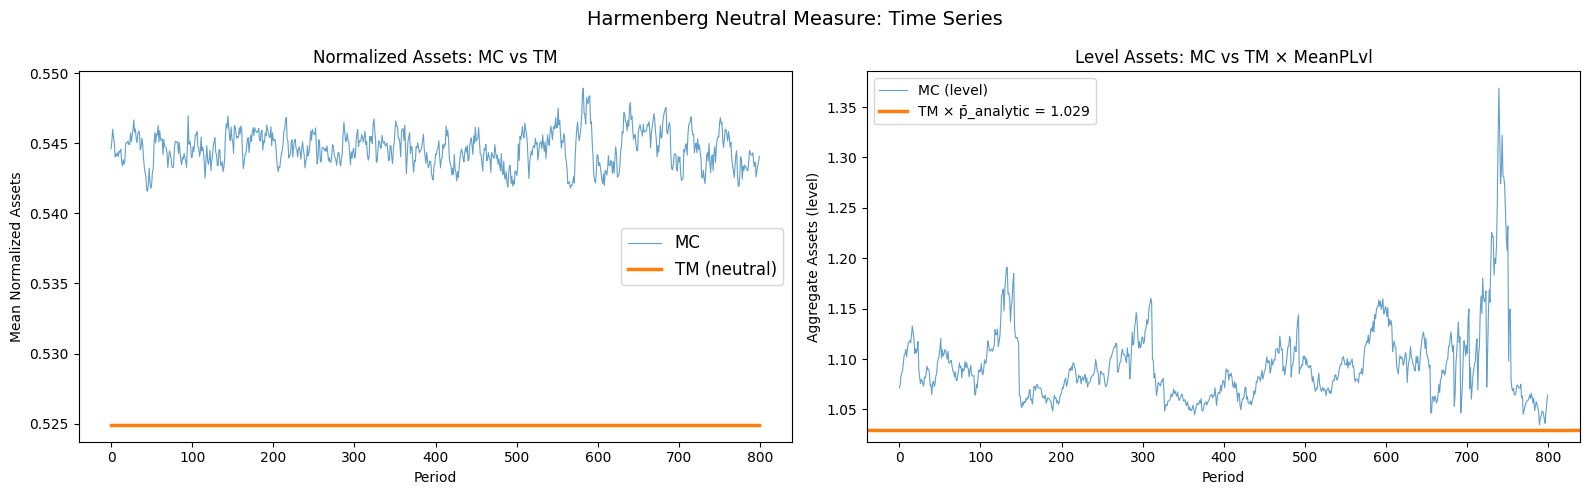

In [14]:
# [mc_vs_tm_harmenberg_time_series]
dstn = ergodic_dist.copy()
tm_aNrm_ts = []
tm_cNrm_ts = []

T_forward = agent.T_sim - BURNIN
for t in range(T_forward):
    A_nrm_t = 0.0
    C_nrm_t = 0.0
    for j in range(J):
        block = dstn[j * M : (j + 1) * M]
        A_nrm_t += np.dot(aPol[j], block)
        C_nrm_t += np.dot(cPol[j], block)
    tm_aNrm_ts.append(A_nrm_t)
    tm_cNrm_ts.append(C_nrm_t)
    dstn = TranMatrix @ dstn

mc_aNrm_ts = np.array([np.mean(agent.history["aNrm"][t]) for t in range(agent.T_sim)])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(
    mc_aNrm_ts[BURNIN:],
    color=COLOR_MC,
    alpha=0.7,
    linewidth=0.8,
    label=f"MC ({n_agents:,} agents)",
)
axes[0].plot(
    tm_aNrm_ts,
    color=COLOR_TM,
    linewidth=2.5,
    label=f"TM neutral ({mCount} m-pts × {J} states)",
)
axes[0].set_xlabel("Period (after burn-in)")
axes[0].set_ylabel("Mean Normalized Assets")
axes[0].set_title("Normalized Assets: MC vs TM")
axes[0].legend(fontsize=10)

axes[1].plot(
    mc_aLvls[BURNIN:],
    color=COLOR_MC,
    alpha=0.7,
    linewidth=0.8,
    label=f"MC level ({n_agents:,} agents)",
)
axes[1].axhline(
    TM_A_lvl_analytic,
    color=COLOR_TM,
    linewidth=2.5,
    label=f"TM × p̄_analytic = {TM_A_lvl_analytic:.3f}",
)
axes[1].set_xlabel("Period (after burn-in)")
axes[1].set_ylabel("Aggregate Assets (level)")
axes[1].set_title("Level Assets: MC vs TM × MeanPLvl")
axes[1].legend(fontsize=10)

plt.suptitle("Harmenberg Neutral Measure: Time Series", fontsize=14)
plt.tight_layout()
plt.show()

## 9. Distribution Comparison

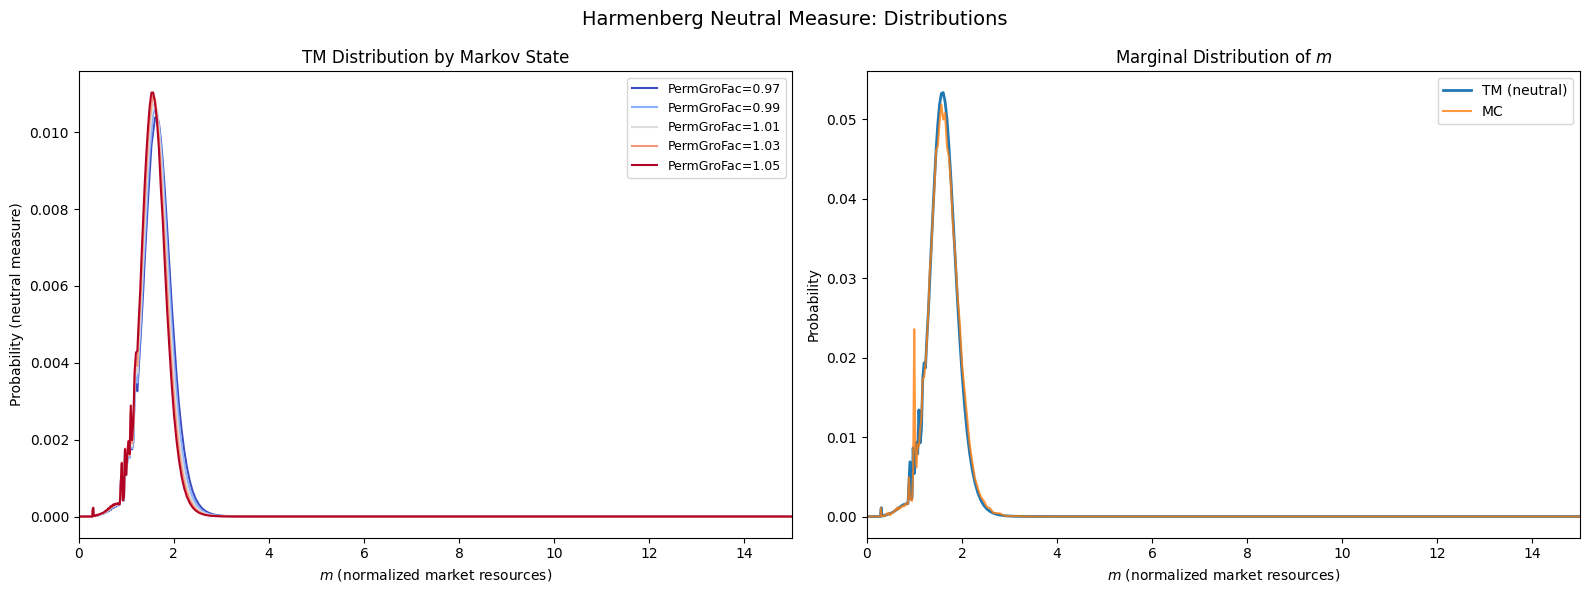

In [15]:
# [harmenberg_neutral_measure_distributions]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Midpoint bin widths for converting mass to density
m_widths = np.zeros(M)
m_widths[0] = dist_mGrid[1] - dist_mGrid[0]
m_widths[-1] = dist_mGrid[-1] - dist_mGrid[-2]
m_widths[1:-1] = 0.5 * (dist_mGrid[2:] - dist_mGrid[:-2])

# Per-state distributions (density under neutral measure)
for j in range(J):
    block = ergodic_dist[j * M : (j + 1) * M]
    density_j = block / m_widths
    color = plt.cm.coolwarm(j / (J - 1))
    axes[0].plot(
        dist_mGrid, density_j, label=state_names[j], color=color, linewidth=1.5
    )
axes[0].set_xlabel("$m$ (normalized market resources)")
axes[0].set_ylabel("Probability Density (neutral measure)")
axes[0].set_title("TM Distribution by Markov State")
axes[0].set_xlim([0, 15])
axes[0].legend(fontsize=9)

# Aggregate m-distribution: TM vs MC (density)
tm_m_marginal = np.zeros(M)
for j in range(J):
    tm_m_marginal += ergodic_dist[j * M : (j + 1) * M]

axes[1].plot(
    dist_mGrid,
    tm_m_marginal / m_widths,
    color=COLOR_TM,
    linewidth=2,
    label=f"TM neutral ({mCount} m-pts)",
)
axes[1].hist(
    agent.state_now["mNrm"],
    bins=N_MC_BINS,
    density=True,
    alpha=0.4,
    color=COLOR_MC,
    label=f"MC ({n_agents:,} agents)",
)
axes[1].set_xlabel("$m$ (normalized market resources)")
axes[1].set_ylabel("Probability Density")
axes[1].set_title("Marginal Distribution of $m$")
axes[1].set_xlim([0, 15])
axes[1].legend()

plt.suptitle("Harmenberg Neutral Measure: Distributions", fontsize=14)
plt.tight_layout()
plt.show()

## 10. Summary: Neutral Measure vs 2D Grid

| Feature | 2D Grid | Neutral Measure |
|---------|---------|-----------------|
| Grid dimensions | $m \times p \times J$ | $m \times J$ |
| States (this model) | 10,000 | 400 (with 200 m-pts) |
| Memory | ~800 MB | ~1.3 MB |
| Normalized aggregates | ✓ accurate | ✓ accurate |
| Level aggregates | ✗ ~30% error (p-grid truncation) | ✓ accurate via $\bar{c} \times \bar{p}$ |
| Build time | ~minutes | ~seconds |

**Key insight:** The 2D grid's failure for level aggregates was caused by the
$p$-grid being too narrow to capture the long right tail.  The neutral measure
avoids this entirely by never discretizing $p$ — it computes $\bar{p}$
analytically instead.

### The Harmenberg recipe

1. **Reweight permanent shocks:** $P^*(\psi_k) = \psi_k \cdot P(\psi_k)$
2. **Build 1D TM** using $m_{t+1} = R \cdot a / (\psi \cdot \Gamma_{j'}) + \theta$ with neutral-measure probabilities
3. **Find ergodic distribution** $\pi^*(m, j)$
4. **Normalized aggregates:** $\bar{c} = E^*[c(m)]$ — read directly from the distribution
5. **Level aggregates:** multiply by $\bar{p} = (1-\lambda) / (1 - \lambda E[\Gamma])$

### Next steps

- Apply neutral measure to `AggShockMarkovConsumerType` (endogenous aggregate state)
- Extend to `NewKeynesianConsumerType` for GE applications
- Compare convergence rates: 1D neutral vs 2D grid as grid density increases